In [2]:
## Import libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np       
import plotly

# 1. Business Understanding
Goal: ?

# 2. Data Understanding

## 2.1 Load dataset

In [3]:
## Read *.csv file into pandas DataFrame
FILE_PATH = "data_reduced_hdb1.csv"
df = pd.read_csv(FILE_PATH)
df

,month,town,flat_type,block,street_name,storey_range,floor_area_sqm,flat_model,lease_commence_date,remaining_lease,resale_price
0,2025-05,YISHUN,5 ROOM,432D,YISHUN AVE 1,04 TO 06,112.0,Improved,2015,89 years 04 months,655000.0
1,2018-11,SENGKANG,EXECUTIVE,306B,ANCHORVALE LINK,04 TO 06,125.0,Apartment,2001,82 years 01 month,520000.0
2,2021-01,PUNGGOL,5 ROOM,161B,PUNGGOL CTRL,16 TO 18,114.0,Premium Apartment,2004,82 years 05 months,510000.0
3,2021-04,SENGKANG,4 ROOM,164C,RIVERVALE CRES,16 TO 18,93.0,Model A,2017,95 years 02 months,470000.0
4,2022-11,TAMPINES,5 ROOM,355,TAMPINES ST 33,04 TO 06,122.0,Improved,1996,72 years 05 months,690000.0
...,...,...,...,...,...,...,...,...,...,...,...
6231,2017-08,JURONG WEST,4 ROOM,923,JURONG WEST ST 92,07 TO 09,104.0,Model A,1989,70 years 05 months,368000.0
6232,2023-10,HOUGANG,4 ROOM,616,HOUGANG AVE 8,04 TO 06,84.0,Simplified,1986,61 years 11 months,470288.0
6233,2022-09,PASIR RIS,4 ROOM,275,PASIR RIS ST 21,01 TO 03,107.0,Model A,1994,71 years,468000.0
6234,2017-11,HOUGANG,4 ROOM,457,HOUGANG AVE 10,10 TO 12,110.0,Model A,1992,73 years 10 months,410000.0


## 2.2 Summary Statistics

In [4]:
## Understand the type of variable for each column
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6236 entries, 0 to 6235
Data columns (total 11 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   month                6236 non-null   object 
 1   town                 6236 non-null   object 
 2   flat_type            6236 non-null   object 
 3   block                6236 non-null   object 
 4   street_name          6236 non-null   object 
 5   storey_range         6236 non-null   object 
 6   floor_area_sqm       6236 non-null   float64
 7   flat_model           6236 non-null   object 
 8   lease_commence_date  6236 non-null   int64  
 9   remaining_lease      6236 non-null   object 
 10  resale_price         6236 non-null   float64
dtypes: float64(2), int64(1), object(8)
memory usage: 536.0+ KB


In [5]:
## Check for missing data
df.isna().sum()

month                  0
town                   0
flat_type              0
block                  0
street_name            0
storey_range           0
floor_area_sqm         0
flat_model             0
lease_commence_date    0
remaining_lease        0
resale_price           0
dtype: int64

In [6]:
## Describe data distribution
df.describe(include='all')

,month,town,flat_type,block,street_name,storey_range,floor_area_sqm,flat_model,lease_commence_date,remaining_lease,resale_price
count,6236,6236,6236,6236,6236,6236,6236.000000,6236,6236.000000,6236,6.236000e+03
unique,101,26,7,1957,531,16,NaN,18,NaN,634,NaN
top,2021-07,SENGKANG,4 ROOM,2,YISHUN RING RD,04 TO 06,NaN,Model A,NaN,94 years 11 months,NaN
freq,97,521,2698,23,74,1431,NaN,2173,NaN,70,NaN
mean,NaN,NaN,NaN,NaN,NaN,NaN,97.338951,NaN,1996.281430,NaN,5.176394e+05
std,NaN,NaN,NaN,NaN,NaN,NaN,23.827991,NaN,14.282942,NaN,1.814538e+05
min,NaN,NaN,NaN,NaN,NaN,NaN,31.000000,NaN,1966.000000,NaN,1.740000e+05
25%,NaN,NaN,NaN,NaN,NaN,NaN,83.000000,NaN,1985.000000,NaN,3.800000e+05
50%,NaN,NaN,NaN,NaN,NaN,NaN,93.000000,NaN,1996.000000,NaN,4.880000e+05
75%,NaN,NaN,NaN,NaN,NaN,NaN,112.000000,NaN,2012.000000,NaN,6.202220e+05


In [7]:
# Drop irrelevant columns
df = df.drop(['month', 'block', 'street_name', 'remaining_lease'], axis =1)

## To make the dataset more manageable
## Keep rows with the towns "TAMPINES", "BEDOK", "PUNGGOL"
df = df[df['town'].isin(['TAMPINES', 'BEDOK', 'PUNGGOL'])]

## Keep rows with the word 'ROOM' in the flat_type column
df = df[df['flat_type'].str.contains('ROOM' , case=False)]

df

,town,flat_type,storey_range,floor_area_sqm,flat_model,lease_commence_date,resale_price
2,PUNGGOL,5 ROOM,16 TO 18,114.0,Premium Apartment,2004,510000.0
4,TAMPINES,5 ROOM,04 TO 06,122.0,Improved,1996,690000.0
12,PUNGGOL,4 ROOM,13 TO 15,92.0,Premium Apartment,2016,510000.0
15,PUNGGOL,4 ROOM,01 TO 03,92.0,Model A,2012,498000.0
20,PUNGGOL,4 ROOM,07 TO 09,96.0,Premium Apartment,2012,668888.0
...,...,...,...,...,...,...,...
6222,PUNGGOL,5 ROOM,01 TO 03,112.0,Improved,2017,585000.0
6223,TAMPINES,5 ROOM,04 TO 06,128.0,Improved,1994,500000.0
6226,BEDOK,5 ROOM,16 TO 18,120.0,Standard,1977,544500.0
6229,BEDOK,3 ROOM,04 TO 06,65.0,Improved,1977,325000.0


## 2.3 Data Visualization

### 2.3.1 Understanding distribution of data

### 2.3.1.1 Understanding distribution of target

array([[<Axes: title={'center': 'floor_area_sqm'}>,
        <Axes: title={'center': 'lease_commence_date'}>],
       [<Axes: title={'center': 'resale_price'}>, <Axes: >]], dtype=object)

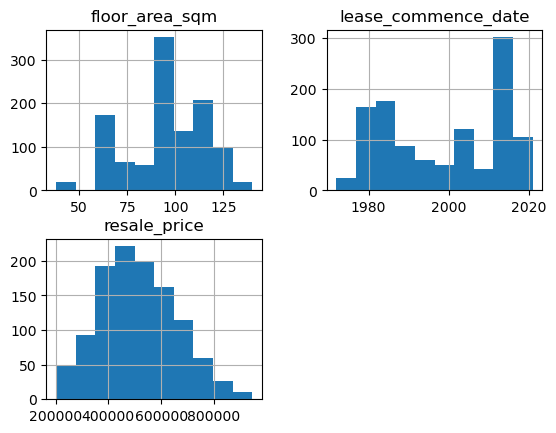

In [8]:
## Understanding distribution of target
df.hist()

### 2.3.1.2 Understanding distribution of features

<Axes: >

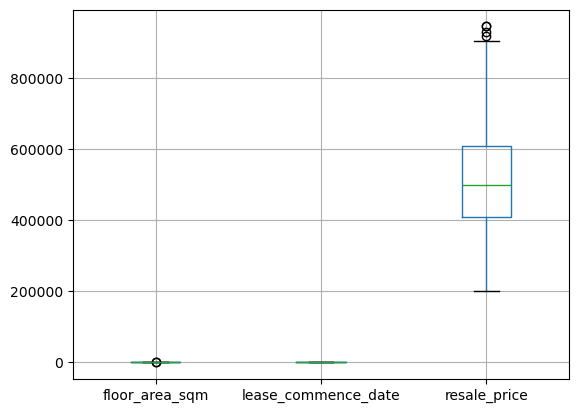

In [9]:
## Understanding distribution of features
df.boxplot()

### 2.3.2 Understanding relationship between variables

<function matplotlib.pyplot.show(close=None, block=None)>

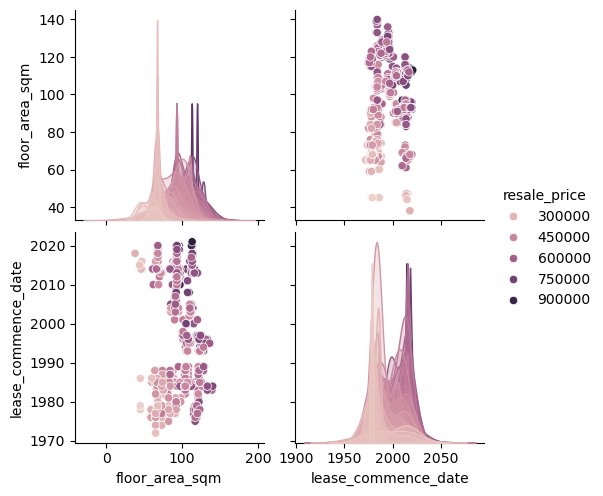

In [10]:
## Understanding relationship between variables
col_y = 'resale_price'
sns.pairplot(df, hue=col_y)
plt.show

# 3. Data Preparation

## 3.1 Data Cleaning

In [11]:
## Split data into features (X) and target (y)
y = df[col_y] ## Select target column
X = df.drop(col_y, axis = 1) ## Select feature column

In [12]:
## Clean data
X = pd.get_dummies(X, drop_first=True)

## 3.2 Train-Test Split

In [13]:
## Split data into train set and test set
from sklearn.model_selection import train_test_split
test_size = 0.3
random_state = 2025
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=test_size, random_state=random_state)

# 4. Modelling

### 4.2 Train Model

In [14]:
## Initialise
from sklearn.tree import DecisionTreeRegressor
dt = DecisionTreeRegressor()
dt.fit(X_train, y_train)

,criterion,'squared_error'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,ccp_alpha,0.0


In [15]:
## Initialise
from sklearn.ensemble import GradientBoostingRegressor
gbt = GradientBoostingRegressor()
gbt.fit(X_train, y_train)


,loss,'squared_error'
,learning_rate,0.1
,n_estimators,100
,subsample,1.0
,criterion,'friedman_mse'
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_depth,3
,min_impurity_decrease,0.0
,init,None


In [16]:
## Initialise
from sklearn.ensemble import RandomForestRegressor
rf = RandomForestRegressor()
rf.fit(X_train, y_train)


,n_estimators,100
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [17]:
## Define parameter grid
param_grid_rf = {
    'n_estimators': [10, 50],
    'criterion': ['sqaure_error', "absolute_error"],
    'max_depth': [1, 2, 3],
    'min_samples_split': [2, 5],
    'max_features': ['sqrt', 'log2']
}

In [18]:
## Initialise model
from sklearn.model_selection import GridSearchCV
gs_rf = GridSearchCV(estimator = rf, param_grid=param_grid_rf, cv=5, scoring='neg_mean_squared_error')
gs_rf.fit(X_train, y_train)

c:\Users\jared\anaconda3\envs\mldp\Lib\site-packages\sklearn\model_selection\_validation.py:516: FitFailedWarning: 
120 fits failed out of a total of 240.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
120 fits failed with the following error:
Traceback (most recent call last):
  File "c:\Users\jared\anaconda3\envs\mldp\Lib\site-packages\sklearn\model_selection\_validation.py", line 859, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
    ~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\jared\anaconda3\envs\mldp\Lib\site-packages\sklearn\base.py", line 1358, in wrapper
    estimator._validate_params()
    ~~~~~~~~~~~~~~~~~~~~~~~~~~^^
  File "c:\Users\jared\anaconda3\envs\mldp\Lib\site-packages\sklearn\b

,estimator,RandomForestRegressor()
,param_grid,"{'criterion': ['sqaure_error', 'absolute_error'], 'max_depth': [1, 2, ...], 'max_features': ['sqrt', 'log2'], 'min_samples_split': [2, 5], ...}"
,scoring,'neg_mean_squared_error'
,n_jobs,None
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,n_estimators,50


In [19]:
## Obtain best parameters and best estimator
best_gs_params = gs_rf.best_params_
best_gs_rf = gs_rf.best_estimator_
print("Best Parameters:", best_gs_params)
print("Best Estimator: ", best_gs_rf )

Best Parameters: {'criterion': 'absolute_error', 'max_depth': 3, 'max_features': 'sqrt', 'min_samples_split': 2, 'n_estimators': 50}
Best Estimator:  RandomForestRegressor(criterion='absolute_error', max_depth=3,
                      max_features='sqrt', n_estimators=50)


In [20]:
## Define parameter distribution
from scipy.stats import randint,uniform

param_dist_rf = {
    'n_estimators': randint(1,5),
    'criterion': ['sqaure_error', "absolute_error"],
    'max_depth': randint(1,3),
    'min_samples_split': randint(2,5),
    'max_features': ['sqrt', 'log2'],
    'max_samples': uniform(0.6, 0.4),
}

In [21]:
## Initialise model
from sklearn.model_selection import RandomizedSearchCV
rs_rf = RandomizedSearchCV(
    estimator= rf,
    param_distributions= param_dist_rf,
    cv=5,
    scoring='neg_mean_squared_error',
    n_iter=10,
    n_jobs=-1
)
rs_rf.fit(X_train, y_train)

c:\Users\jared\anaconda3\envs\mldp\Lib\site-packages\sklearn\model_selection\_validation.py:516: FitFailedWarning: 
25 fits failed out of a total of 50.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
2 fits failed with the following error:
Traceback (most recent call last):
  File "c:\Users\jared\anaconda3\envs\mldp\Lib\site-packages\sklearn\model_selection\_validation.py", line 859, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
    ~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\jared\anaconda3\envs\mldp\Lib\site-packages\sklearn\base.py", line 1358, in wrapper
    estimator._validate_params()
    ~~~~~~~~~~~~~~~~~~~~~~~~~~^^
  File "c:\Users\jared\anaconda3\envs\mldp\Lib\site-packages\sklearn\base.

,estimator,RandomForestRegressor()
,param_distributions,"{'criterion': ['sqaure_error', 'absolute_error'], 'max_depth': <scipy.stats....002163A4896D0>, 'max_features': ['sqrt', 'log2'], 'max_samples': <scipy.stats....002163A2FFE00>, ...}"
,n_iter,10
,scoring,'neg_mean_squared_error'
,n_jobs,-1
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,random_state,None
,error_score,nan


In [23]:
## Obtain best parameters and best estimator
best_rs_params = rs_rf.best_params_
best_rs_rf = rs_rf.best_estimator_
print("Best Parameters:", best_rs_params)
print("Best Estimator: ", best_rs_rf )

Best Parameters: {'criterion': 'absolute_error', 'max_depth': 2, 'max_features': 'log2', 'max_samples': np.float64(0.8788938850089387), 'min_samples_split': 4, 'n_estimators': 4}
Best Estimator:  RandomForestRegressor(criterion='absolute_error', max_depth=2,
                      max_features='log2',
                      max_samples=np.float64(0.8788938850089387),
                      min_samples_split=4, n_estimators=4)


# 5. Model Evaluation

In [24]:
## Predict Value for evaluation
y_pred_dt = dt.predict(X_test)

In [25]:
## Predict Value for evaluation
y_pred_gbt = gbt.predict(X_test)

In [26]:
## Predict Value for evaluation
y_pred_rf = rf.predict(X_test)

In [27]:
from sklearn.metrics import mean_absolute_error

In [28]:
## Evaluate model
mean_absolute_error(y_test, y_pred_dt)

81240.53890995926

In [29]:
## Evaluate model
mean_absolute_error(y_test, y_pred_gbt)

64675.15654750549

In [30]:
## Evaluate model
mean_absolute_error(y_test, y_pred_rf)

65950.00288985597

In [31]:
# Save model
import joblib
joblib.dump(best_gs_rf, 'hdb_best_gs_rf_model.pk1')

['hdb_best_gs_rf_model.pk1']

In [32]:
# Save model
import joblib
joblib.dump(best_rs_rf, 'hdb_best_rs_rf_model.pk1')

['hdb_best_rs_rf_model.pk1']

In [33]:
## Predict

## Convert to OHE Pandas Dataframe
X_unseen = pd.read_csv(FILE_PATH)

col_df_X = df.drop(col_y, axis =1).columns
col_ohe = X.columns.tolist()
X_unseen = pd.DataFrame(X_unseen, columns=col_df_X)
X_unseen = pd.get_dummies(X_unseen, drop_first=True)
X_unseen = X_unseen.reindex(columns=col_ohe, fill_value=0)
## Predict for unseen data
X_unseen['Predicted Price'] = rf.predict(X_unseen)

## Compare with groundtruth
y_unseen = pd.read_csv(FILE_PATH)
X_unseen['Actual'] = y_unseen[col_y]
X_unseen

,floor_area_sqm,lease_commence_date,town_PUNGGOL,town_TAMPINES,flat_type_3 ROOM,flat_type_4 ROOM,flat_type_5 ROOM,storey_range_04 TO 06,storey_range_07 TO 09,storey_range_10 TO 12,...,flat_model_DBSS,flat_model_Improved,flat_model_Model A,flat_model_Model A-Maisonette,flat_model_New Generation,flat_model_Premium Apartment,flat_model_Simplified,flat_model_Standard,Predicted Price,Actual
0,112.0,2015,False,False,False,False,True,True,False,False,...,False,True,False,False,False,False,False,False,719502.964000,655000.0
1,125.0,2001,False,False,False,False,False,True,False,False,...,False,False,False,False,False,False,False,False,654429.426667,520000.0
2,114.0,2004,True,False,False,False,True,False,False,False,...,False,False,False,False,False,True,False,False,534074.833333,510000.0
3,93.0,2017,False,False,False,True,False,False,False,False,...,False,False,True,False,False,False,False,False,618689.567619,470000.0
4,122.0,1996,False,True,False,False,True,True,False,False,...,False,True,False,False,False,False,False,False,656745.444000,690000.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6231,104.0,1989,False,False,False,True,False,False,True,False,...,False,False,True,False,False,False,False,False,577648.333333,368000.0
6232,84.0,1986,False,False,False,True,False,True,False,False,...,False,False,False,False,False,False,True,False,483258.320000,470288.0
6233,107.0,1994,False,False,False,True,False,False,False,False,...,False,False,True,False,False,False,False,False,491957.333333,468000.0
6234,110.0,1992,False,False,False,True,False,False,False,True,...,False,False,True,False,False,False,False,False,519253.115440,410000.0
